***Import libraries***



In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense,
    BatchNormalization, Dropout, Activation,
    GlobalAveragePooling2D
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from sklearn.metrics import classification_report

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


***Dataset Path***


In [3]:
import os
print(os.path.exists("/content/drive/MyDrive/ Ai and machine learning/FruitinAmazon.zip"))

True


In [6]:
from google.colab import files
files.upload()

Saving FruitinAmazon.zip to FruitinAmazon.zip


{'FruitinAmazon.zip': b'PK\x03\x04\x14\x00\x08\x08\x08\x00\x00\x00!\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00,\x00b\x00FruitinAmazon/test/cupuacu/download (5).jpegUT\x05\x00\x01B\x1d\xa4_\n\x00 \x00\x00\x00\x00\x00\x01\x00\x18\x00\x00\xcd\xa1/\x8a\xb3\xd6\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00up1\x00\x01\x98n\xb6\x10FruitinAmazon/test/cupuacu/download (5).jpeg\x01\xca(5\xd7\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00\x84\x00\t\x06\x07\x13\x13\x12\x15\x13\x13\x14\x15\x15\x15\x17\x19\x1d\x1a\x18\x18\x18\x17\x1a\x1b\x1a\x1a\x1e\x18\x19\x1e\x17\x18\x18\x17\x17\x1d\x1d( \x18\x1a%\x1d\x1a\x18!1!%)+...\x18\x1f383-7(-.+\x01\n\n\n\x0e\r\x0e\x1b\x10\x10\x1b-%\x1f%------/-------------------------------------------\xff\xc0\x00\x11\x08\x00\xc2\x01\x03\x03\x01"\x00\x02\x11\x01\x03\x11\x01\xff\xc4\x00\x1c\x00\x00\x02\x02\x03\x01\x01\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x04\x05\x03\x06\x00\x01\x02\x07\x08\xff\xc4\x00=\x10\x0

In [7]:
import zipfile

zip_path = "/content/FruitinAmazon.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [8]:
import os
print(os.listdir("/content/dataset"))

['FruitinAmazon']


In [9]:
print(os.listdir("/content/dataset/FruitinAmazon"))

['train', 'test']


In [10]:
train_dir = "/content/dataset/train"
test_dir  = "/content/dataset/test"

In [11]:
train_dir = "/content/dataset/FruitinAmazon/train"
test_dir  = "/content/dataset/FruitinAmazon/test"

In [12]:
print(os.listdir(train_dir))

['graviola', 'guarana', 'acai', 'pupunha', 'cupuacu', 'tucuma']


***Part A — Dataset Understanding and Visualization***

***Read dataset directory and class names***

In [13]:
class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)

if not class_names:
    print("No class directories found in the train folder!")
else:
    print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


***Check corrupted images***


In [14]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = os.listdir(class_path)

        for img_name in images:
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError):
                corrupted_images.append(img_path)

if corrupted_images:
    print("\nCorrupted Images Found:")
    for img in corrupted_images:
        print(img)
else:
    print("\nNo corrupted images found.")


No corrupted images found.


***Check class distribution***

In [15]:
class_counts = {}

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
        class_counts[class_name] = len(images)

print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid Image Count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)


Class Distribution:
Class Name               Valid Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


***Select one random image from each class***

In [16]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        images = [
            img for img in os.listdir(class_path)
            if img.lower().endswith((".png", ".jpg", ".jpeg"))
        ]

        if images:
            selected_img = os.path.join(class_path, random.choice(images))
            selected_images.append(selected_img)
            selected_labels.append(class_name)

***Plot random images***

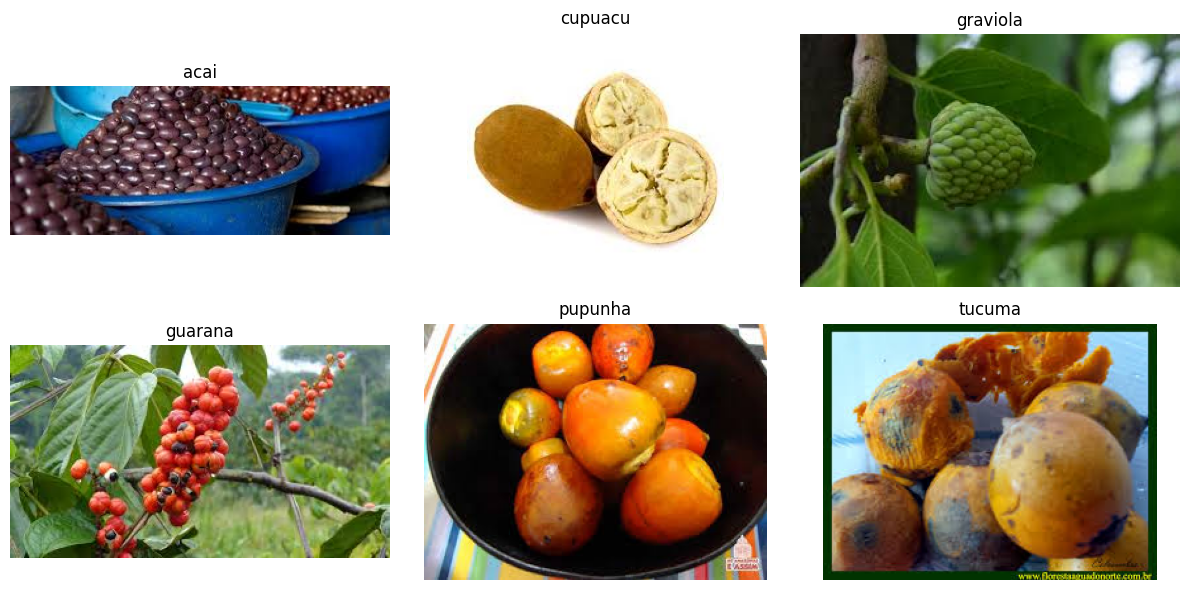

In [17]:
num_classes = len(selected_images)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_classes:
        img = mpimg.imread(selected_images[i])
        ax.imshow(img)
        ax.set_title(selected_labels[i])
        ax.axis("off")
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

***Part B — Data Generation and Pre-processing***

***Create train and validation datasets***

In [18]:
image_size = (28, 28)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale"
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    color_mode="grayscale"
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


***Create test dataset***

In [19]:
test_ds = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False,
    color_mode="grayscale"
)

Found 30 files belonging to 6 classes.


***Check dataset batch shape***

In [20]:
for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)

Images shape: (32, 28, 28, 1)
Labels shape: (32,)


***Visualize training dataset***

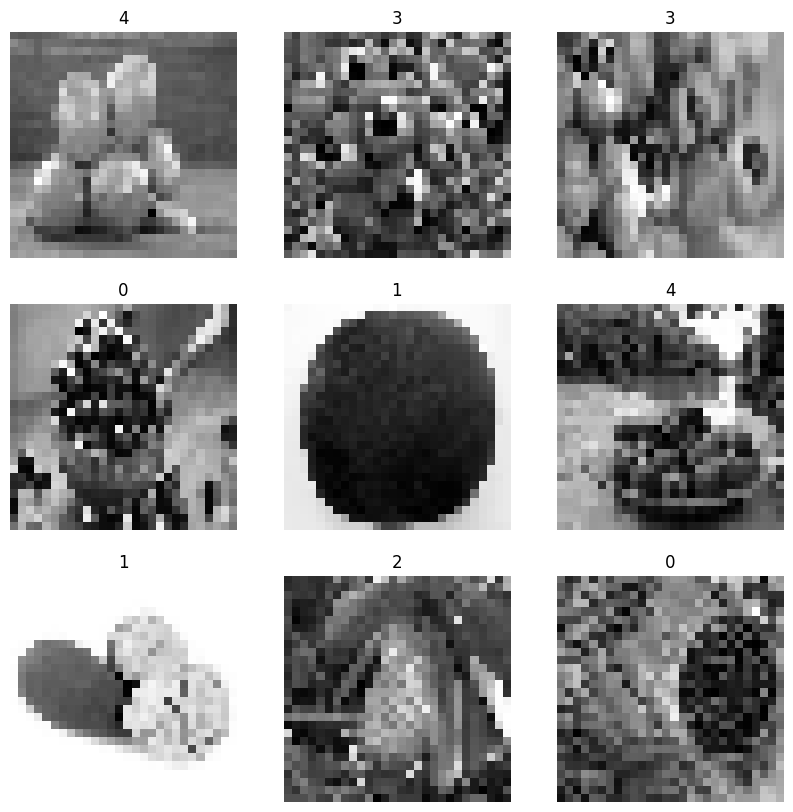

In [21]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8").squeeze(), cmap="gray")
        plt.title(int(labels[i]))
        plt.axis("off")

plt.show()

***Part C — Data Augmentation***

In [22]:
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

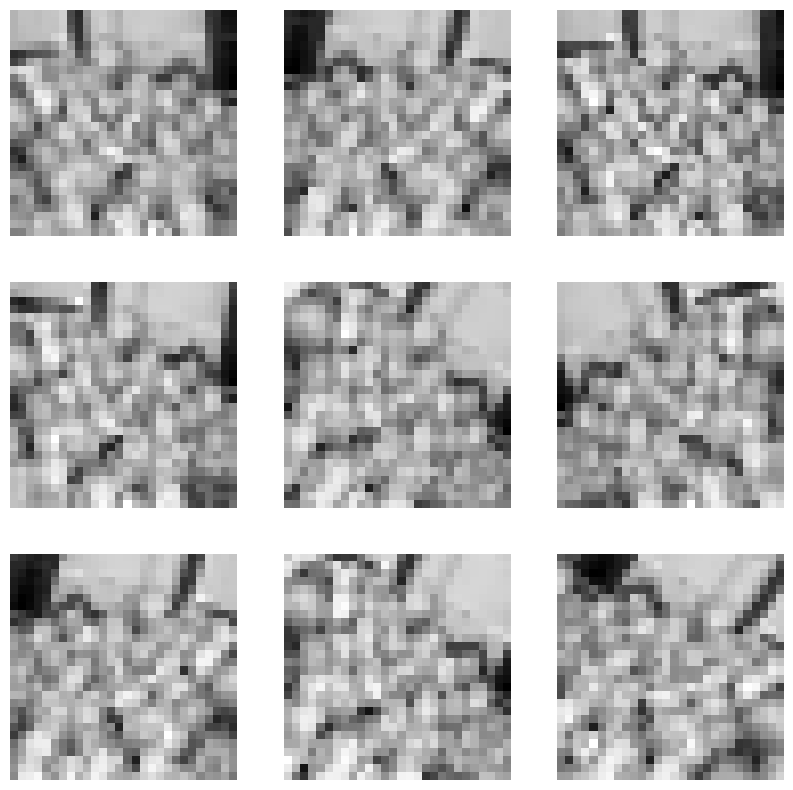

In [23]:
plt.figure(figsize=(10, 10))

for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8").squeeze(), cmap="gray")
        plt.axis("off")

plt.show()

***Part D — Improved CNN Model with BN and Dropout***

***improved CNN***

In [24]:
num_classes = len(class_names)

model = Sequential([
    layers.Lambda(data_augmentation, input_shape=(28, 28, 1)),
    layers.Rescaling(1./255),

    Conv2D(32, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(128, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(256, (3, 3), padding='same', activation=None),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(512, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(256, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(64, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 3, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 3, 3, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 1, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             

 Total params: 698,054 (2.66 MB)

 Trainable params: 695,174 (2.65 MB)

 Non-trainable params: 2,880 (11.25 KB)

***Train the CNN model***

In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step - accuracy: 0.1806 - loss: 2.4967 - val_accuracy: 0.0556 - val_loss: 1.7938
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1389 - loss: 2.2408 - val_accuracy: 0.2222 - val_loss: 1.7900
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.1389 - loss: 2.2726 - val_accuracy: 0.2778 - val_loss: 1.7881
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1806 - loss: 2.4642 - val_accuracy: 0.2222 - val_loss: 1.7879
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1806 - loss: 2.2495 - val_accuracy: 0.0556 - val_loss: 1.7858
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.1250 - loss: 2.5824 - val_accuracy: 0.0556 - val_loss: 1.7872
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.1389 - loss: 2.3040 - val_accuracy: 0.0556 - val_loss: 1.7935
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.2500 - loss: 2.2139 - val_accuracy: 0.0556 - val_loss: 1.7947

***Plot accuracy graph***

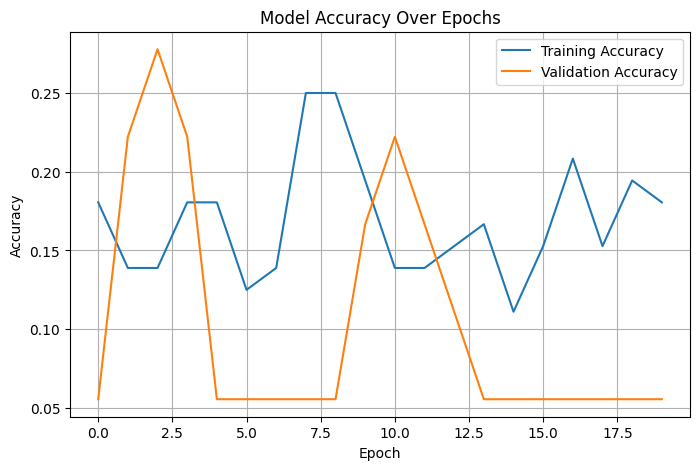

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

***Plot loss graph***

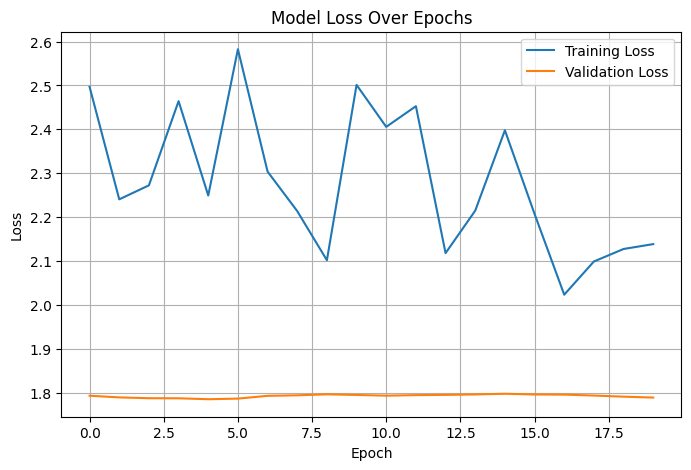

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

***Evaluate CNN model***

In [28]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1333 - loss: 1.7928
Test Loss: 1.7928
Test Accuracy: 0.1333


***Generate inference output***

In [29]:
predictions = model.predict(test_ds)
predicted_labels = np.argmax(predictions, axis=1)

print("Predicted labels:")
print(predicted_labels[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
Predicted labels:
[3 3 4 4 3 3 3 3 3 3 3 3 3 3 3 3 3 4 3 4]


***Classification report for CNN***

In [30]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

print(classification_report(y_true, predicted_labels, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         5
     cupuacu       0.00      0.00      0.00         5
    graviola       0.00      0.00      0.00         5
     guarana       0.12      0.60      0.21         5
     pupunha       0.17      0.20      0.18         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.13        30
   macro avg       0.05      0.13      0.06        30
weighted avg       0.05      0.13      0.06        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


***Transfer Learning with VGG16***

***Create VGG16 datasets***

In [31]:
vgg_image_size = (224, 224)
batch_size = 32

train_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=vgg_image_size,
    batch_size=batch_size,
    color_mode="rgb"
)

val_vgg = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=vgg_image_size,
    batch_size=batch_size,
    color_mode="rgb"
)

test_vgg = keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=vgg_image_size,
    batch_size=batch_size,
    shuffle=False,
    color_mode="rgb"
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


***Load pretrained VGG16***

In [32]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


***Freeze the layers***

In [33]:
for layer in base_model.layers:
    layer.trainable = False

***Add custom layers***

In [34]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)

***Create final VGG16 model***

In [35]:
model_vgg = Model(inputs=base_model.input, outputs=x)

***Compile VGG16 model***

In [36]:
model_vgg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_vgg.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,246,150 (58.16 MB)

 Trainable params: 531,462 (2.03 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

***Train VGG16 model***

In [37]:
train_vgg = keras.utils.image_dataset_from_directory(
    "/content/dataset/FruitinAmazon/train",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    color_mode="rgb"
)

val_vgg = keras.utils.image_dataset_from_directory(
    "/content/dataset/FruitinAmazon/train",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    color_mode="rgb"
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [38]:
history_vgg = model_vgg.fit(
    train_vgg,
    validation_data=val_vgg,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.2778 - loss: 5.1358 - val_accuracy: 0.3889 - val_loss: 7.2920
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 0.6944 - loss: 2.6338 - val_accuracy: 0.3889 - val_loss: 7.0955
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 13s/step - accuracy: 0.8333 - loss: 1.0486 - val_accuracy: 0.5000 - val_loss: 4.0613
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 42s 14s/step - accuracy: 0.9861 - loss: 0.0614 - val_accuracy: 0.5556 - val_loss: 2.7902
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.9861 - loss: 0.0984 - val_accuracy: 0.6111 - val_loss: 2.5740
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 12s/step - accuracy: 0.9583 - loss: 0.1557 - val_accuracy: 0.6667 - val_loss: 3.1273
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 13s/step - accuracy: 0.9722 - loss: 0.0431 - val_accuracy: 0.6111 - val_loss: 3.7573
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 12s/step - accuracy: 1.0000 - loss: 0.0096 - val_accuracy: 0.6111 - val_loss: 4.2132


***Evaluate VGG16***

In [39]:
vgg_loss, vgg_acc = model_vgg.evaluate(test_vgg)
print(f"VGG16 Test Loss: {vgg_loss:.4f}")
print(f"VGG16 Test Accuracy: {vgg_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step - accuracy: 0.5667 - loss: 3.3758
VGG16 Test Loss: 3.3758
VGG16 Test Accuracy: 0.5667


***Generate inference output for VGG16***

In [40]:
vgg_predictions = model_vgg.predict(test_vgg)
vgg_predicted_labels = np.argmax(vgg_predictions, axis=1)

print("Predicted labels from VGG16:")
print(vgg_predicted_labels[:20])

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step
Predicted labels from VGG16:
[0 0 1 0 0 1 1 1 1 5 2 1 2 0 0 3 3 3 3 0]


***Classification report for VGG16***

In [41]:
y_true_vgg = np.concatenate([y for x, y in test_vgg], axis=0)

print(classification_report(y_true_vgg, vgg_predicted_labels, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.44      0.80      0.57         5
     cupuacu       0.57      0.80      0.67         5
    graviola       1.00      0.40      0.57         5
     guarana       0.67      0.80      0.73         5
     pupunha       0.00      0.00      0.00         5
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.57        30
   macro avg       0.53      0.57      0.51        30
weighted avg       0.53      0.57      0.51        30



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


***Compare performance***

In [42]:
print("CNN Test Accuracy:", test_acc)
print("Vgg16 Test Accuracy:", vgg_acc)

CNN Test Accuracy: 0.13333334028720856
Vgg16 Test Accuracy: 0.5666666626930237
